previsão de categorias nos tweets #edtwt

In [1]:
%pip install scikit-learn pandas numpy matplotlib seaborn --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

STOPWORDS_PT = frozenset("""
a ao aos aquela aquelas aquele aqueles aquilo as até com como contra
da das de dela delas dele deles depois do dos e ela elas ele eles em
entre era eram essa essas esse esses esta estamos estão estas estava
estavam este esteja estejam estes esteve estivemos estiver estiveram
estivesse estivessem estivermos estivéssemos estou está estávamos eu
fomos for fora foram fosse fossem fôssemos fui há isso isto já lá mas
me mesmo meu meus minha minhas mais menos na não nas nem no nos nós
nossa nossas nosso nossos num numa o os ou para pela pelas pelo pelos
por quando que quem são se seja sejam sem serei será serão seria seriam
seríamos seu seus só também te tem temos tenham tendo ter teu teus ti
tive tivemos tiver tiveram tivesse tivessem tivéssemos tu tua tuas um
uma você vocês vos à às é és
""".split())

import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

CATEGORIAS = ["pro-ed", "pro-recovery"]
print('dependências carregadas.')

dependências carregadas.


carregamento dos dados classificados

In [3]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, "tweets_classificacao.csv")

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"Arquivo não encontrado: {csv_path}\n"
        "Execute o notebook 8-classificador.ipynb primeiro para gerar o tweets_classificacao.csv."
    )

df = pd.read_csv(csv_path)
df = df.dropna(subset=["categoria"]).reset_index(drop=True)
n_total = len(df)
df = df[df["categoria"] != "neutro"].reset_index(drop=True)

print(f"Tweets rotulados: {n_total}  |  após remover neutros: {len(df)} (pro-ed vs pro-recovery)")
print("\nDistribuição por categoria:")
print(df["categoria"].value_counts().reindex(CATEGORIAS, fill_value=0))
df[["text_redacted", "categoria"]].head()

Tweets rotulados: 149  |  após remover neutros: 65 (pro-ed vs pro-recovery)

Distribuição por categoria:
categoria
pro-ed          61
pro-recovery     4
Name: count, dtype: int64


,text_redacted,categoria
0,Eu preciso emagrecer [hashtag],pro-ed
1,Ed sinceridade eu to gorda nessa foto? E quant...,pro-ed
2,[mention] [mention] Essa vai pro [hashtag],pro-ed
3,"[mention] esmagrici 7kg em 2 semanas, estou qu...",pro-ed
4,"Nuh dei uma sumida daqui, deve ser a terapia. ...",pro-ed


divisão treino/teste

In [4]:
SEED = 42
X = df["text_redacted"].astype(str)
y = df["categoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"treino: {len(X_train)} tweets  |  teste: {len(X_test)} tweets")
print("\nProporção no treino:")
print(y_train.value_counts(normalize=True).reindex(CATEGORIAS, fill_value=0).round(3))

treino: 52 tweets  |  teste: 13 tweets

Proporção no treino:
categoria
pro-ed          0.942
pro-recovery    0.058
Name: proportion, dtype: float64


extração de features (tf-idf)

In [5]:
vetorizador = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    stop_words=list(STOPWORDS_PT),
)

X_train_tfidf = vetorizador.fit_transform(X_train)
X_test_tfidf = vetorizador.transform(X_test)
print(f"vocabulário tf-idf: {len(vetorizador.vocabulary_)} features")
print(f"matriz treino: {X_train_tfidf.shape}  |  matriz teste: {X_test_tfidf.shape}")

vocabulário tf-idf: 79 features
matriz treino: (52, 79)  |  matriz teste: (13, 79)


treinamento dos modelos

In [6]:
modelos = {
    "Regressão Logística": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED
    ),
    "SVM Linear": LinearSVC(class_weight="balanced", random_state=SEED),
}

previsoes = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    previsoes[nome] = modelo.predict(X_test_tfidf)
    acc = accuracy_score(y_test, previsoes[nome])
    f1m = f1_score(y_test, previsoes[nome], average="macro")
    print(f"{nome:22s}  acurácia={acc:.3f}  f1-macro={f1m:.3f}")

Regressão Logística     acurácia=0.923  f1-macro=0.480
SVM Linear              acurácia=0.923  f1-macro=0.480


relatório de classificação

In [7]:
for nome in modelos:
    print(f"===== {nome} =====")
    print(classification_report(y_test, previsoes[nome], labels=CATEGORIAS, zero_division=0))
    print()

===== Regressão Logística =====
              precision    recall  f1-score   support

      pro-ed       0.92      1.00      0.96        12
pro-recovery       0.00      0.00      0.00         1

    accuracy                           0.92        13
   macro avg       0.46      0.50      0.48        13
weighted avg       0.85      0.92      0.89        13


===== SVM Linear =====
              precision    recall  f1-score   support

      pro-ed       0.92      1.00      0.96        12
pro-recovery       0.00      0.00      0.00         1

    accuracy                           0.92        13
   macro avg       0.46      0.50      0.48        13
weighted avg       0.85      0.92      0.89        13




matriz de confusão

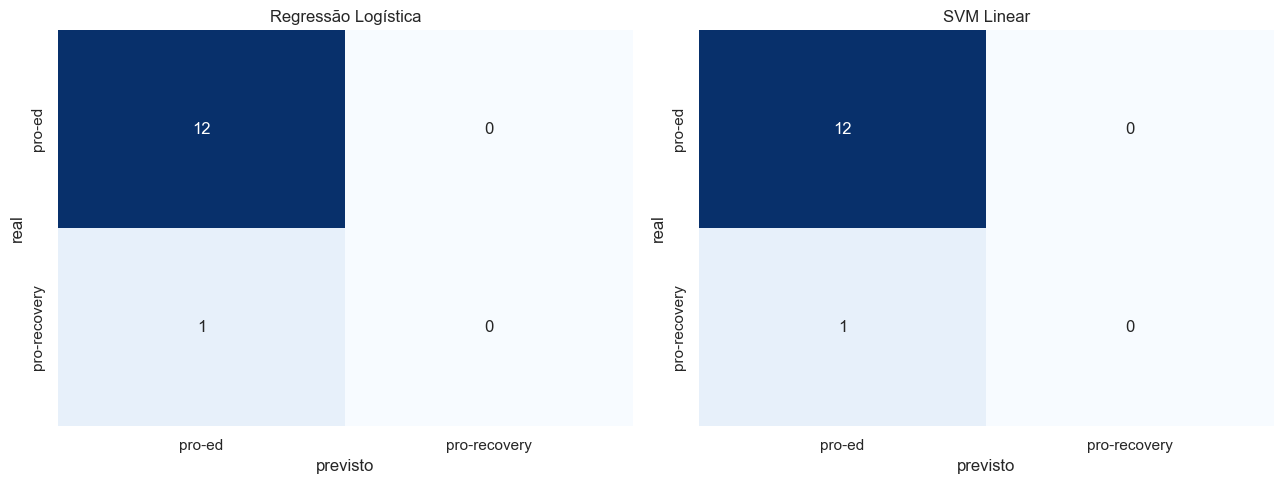

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, nome in zip(axes, modelos):
    cm = confusion_matrix(y_test, previsoes[nome], labels=CATEGORIAS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CATEGORIAS, yticklabels=CATEGORIAS, ax=ax, cbar=False)
    ax.set_title(nome)
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")
plt.tight_layout()
plt.show()

comparação de f1 por classe

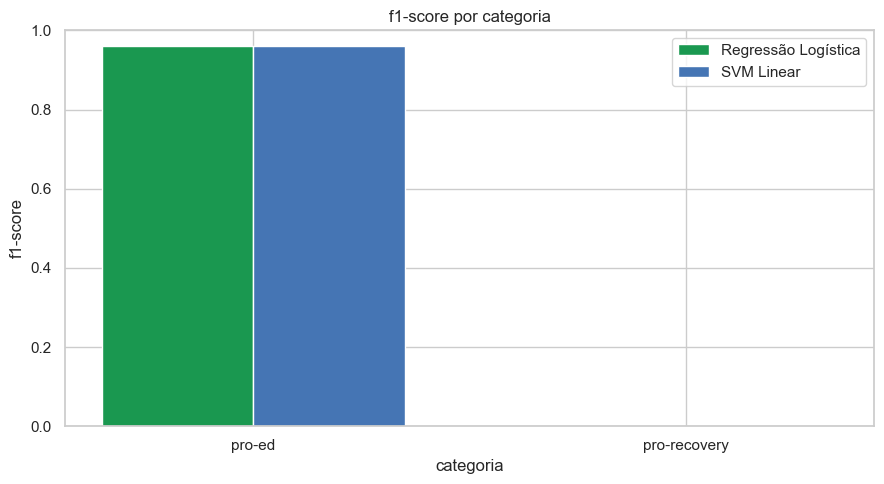

In [9]:
f1_por_classe = {nome: f1_score(y_test, previsoes[nome], labels=CATEGORIAS, average=None)
               for nome in modelos}

x = np.arange(len(CATEGORIAS))
largura = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - largura / 2, f1_por_classe["Regressão Logística"], largura,
       label="Regressão Logística", color="#1a9850")
ax.bar(x + largura / 2, f1_por_classe["SVM Linear"], largura,
       label="SVM Linear", color="#4575b4")
ax.set_xticks(x)
ax.set_xticklabels(CATEGORIAS)
ax.set_ylim(0, 1)
ax.set_title("f1-score por categoria")
ax.set_xlabel("categoria")
ax.set_ylabel("f1-score")
ax.legend()
plt.tight_layout()
plt.show()

validação cruzada (5 folds)

In [10]:
pipelines = {
    "Regressão Logística": Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, stop_words=list(STOPWORDS_PT))),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ]),
    "SVM Linear": Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, stop_words=list(STOPWORDS_PT))),
        ("clf", LinearSVC(class_weight="balanced", random_state=SEED)),
    ]),
}

print("validação cruzada (5 folds, f1-macro) sobre todos os tweets rotulados:")
for nome, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring="f1_macro")
    print(f"  {nome:22s}  f1-macro = {scores.mean():.3f} ± {scores.std():.3f}")

validação cruzada (5 folds, f1-macro) sobre todos os tweets rotulados:
  Regressão Logística     f1-macro = 0.462 ± 0.017
  SVM Linear              f1-macro = 0.533 ± 0.140
